<p style="align: center;"><img src="https://static.tildacdn.com/tild6636-3531-4239-b465-376364646465/Deep_Learning_School.png" width="400"></p>

# Глубокое обучение. Часть 2
# Домашнее задание по теме "Механизм внимания"

Это домашнее задание проходит в формате peer-review. Это означает, что его будут проверять ваши однокурсники. Поэтому пишите разборчивый код, добавляйте комментарии и пишите выводы после проделанной работы.

В этом задании вы будете решать задачу классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

В качестве датасета возьмем датасет математических задач по разным темам. Нам необходим следующий файл:

[Файл с классами](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true)

**Hint:** не перезаписывайте модели, которые вы получите на каждом из этапов этого дз. Они ещё понадобятся.

### Задание 1 (2 балла)

Напишите кастомный класс для модели трансформера для задачи классификации, использующей в качествке backbone какую-то из моделей huggingface.

Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone (достаточно возможности использовать в качестве backbone те модели, которые упомянуты в последующих пунктах)

In [1]:
import torch
import torch.nn as nn
from typing import Union, List, Dict
from transformers import AutoTokenizer, AutoModel, TrainingArguments, DataCollatorWithPadding, Trainer
from datasets import Dataset
from sklearn.preprocessing import LabelEncoder
import copy
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_excel('/kaggle/input/datasets/tahmazova/data-problems-translated/data_problems_translated.xlsx')
data

,Unnamed: 0,problem_text,topic
0,0,To prove that the sum of the numbers of the ex...,number_theory
1,1,( b) Will the statement of the previous challe...,number_theory
2,2,The quadratic three-member graph with the coef...,polynoms
3,3,Can you draw on the surface of Rubik's cube a ...,combinatorics
4,4,"Dima, who came from Vrunlandia, said that ther...",graphs
...,...,...,...
5268,5268,Can the number n! end with the figures of 76.0...,number_theory
5269,5269,Find all natural m and n for which m! + 12 = n2.,number_theory
5270,5270,"The correct 5,000-column has a 2001 vertebrate...",dirichlet
5271,5271,Find the maximum number N for which there are ...,number_theory


In [3]:
# Извлекаем тексты и метрики
texts = data['problem_text'].tolist()
topics = data['topic'].tolist()

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [5]:
class TransformerClassificationModel(nn.Module):
    def __init__(
        self,
        base_transformer_model: Union[str, nn.Module],
        num_classes: int,
        dropout_value: float = 0.1,
    ) -> None:
        super().__init__()
        self.backbone = AutoModel.from_pretrained(
            base_transformer_model,
            attn_implementation="eager"
        )
        self.hidden_size = self.backbone.config.hidden_size

        self.dropout = nn.Dropout(dropout_value)

        # Вход - вектор из трансформера, выход - оценки для классов
        self.classifier = nn.Linear(self.hidden_size, num_classes)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        labels: torch.Tensor | None = None,
        output_attentions: bool = False,
        **kwargs,
    ) -> Dict[str, torch.Tensor]:
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=output_attentions,
            **kwargs
        )
        # Берем вектор первого токена (CLS)
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        cls_embedding = self.dropout(cls_embedding)


        logits = self.classifier(cls_embedding)

        loss = None
        if labels is not None:
            loss = nn.CrossEntropyLoss()(logits, labels)

        result = {"loss": loss, "logits": logits}

        if output_attentions and hasattr(outputs, 'attentions'):
          result['attentions'] = outputs.attentions
        return result

### Задание 2 (1 балл)

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [6]:
def freeze_backbone_function(
    model: TransformerClassificationModel,
    freeze: bool,
) -> TransformerClassificationModel:
    for param in model.backbone.parameters():
      # Если freeze=True, отключаем градиенты (замораживаем параметры)
      # Т.е. freeze = True -> requires_grad = False
      param.requires_grad = not freeze
    return model

### Задание 3 (2 балла)

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [7]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = predictions.argmax(axis=1)
    return {"accuracy": (preds == labels).mean()}

In [8]:
def train_transformer(
    transformer_model: TransformerClassificationModel,
    training_args: TrainingArguments,
    train_dataset: Dataset,
    eval_dataset: Dataset,
    data_collator: DataCollatorWithPadding,
    freeze_backbone: bool = True,
) -> TransformerClassificationModel:
    model = copy.deepcopy(transformer_model)
    model.to(device)

    freeze_backbone_function(model, freeze=freeze_backbone)

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()

    return model

### Задание 4 (1 балл)

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [9]:
texts = data['problem_text'].fillna('').astype(str).tolist()

In [10]:
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(topics)
num_classes = len(label_encoder.classes_)

In [11]:
def prepare_hf_dataset(
    texts: List[str],
    labels: List[int],
    tokenizer: AutoTokenizer,
    max_length: int = 128,
) -> Dataset:
    encodings = tokenizer(
        texts,
        padding=False,
        truncation=True,
        max_length=max_length,
    )
    return Dataset.from_dict({
        'input_ids': encodings['input_ids'],
        'attention_mask': encodings['attention_mask'],
        'labels': labels
    })

In [12]:
split_idx = int(0.8 * len(texts))
train_texts = texts[:split_idx]
train_labels = encoded_labels[:split_idx]
val_texts = texts[split_idx:]
val_labels = encoded_labels[split_idx:]

In [13]:
tokenizer = AutoTokenizer.from_pretrained('cointegrated/rubert-tiny2')

train_dataset = prepare_hf_dataset(train_texts, train_labels, tokenizer)
val_dataset = prepare_hf_dataset(val_texts, val_labels, tokenizer)

data_collator = DataCollatorWithPadding(tokenizer)

# Аргументы обучения для замороженного backbone
training_args_frozen = TrainingArguments(
    output_dir="./rubert_frozen",
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    logging_strategy="epoch",
    report_to="none",
)

# Аргументы обучения для размороженного backbone
training_args_unfrozen = TrainingArguments(
    output_dir="./rubert_unfrozen",
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,  # Много параметров
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    logging_strategy="epoch",
    report_to="none",
)

rubert_tiny_transformer_model = TransformerClassificationModel(
    'cointegrated/rubert-tiny2',
    num_classes=num_classes,
)

rubert_tiny_transformer_model2 = TransformerClassificationModel(
    'cointegrated/rubert-tiny2',
    num_classes=num_classes
)

# Обучение с замороженным backbone
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    transformer_model=rubert_tiny_transformer_model,
    training_args=training_args_frozen,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    freeze_backbone=True,
)

# Обучение с размороженным backbone
rubert_tiny_full_finetuned = train_transformer(
    transformer_model=rubert_tiny_transformer_model2,
    training_args=training_args_unfrozen,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    freeze_backbone=False,
)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.648596,1.483259,0.455924
2,1.437119,1.383319,0.496682
3,1.356824,1.320713,0.524171
4,1.304887,1.284000,0.530806
5,1.272282,1.260760,0.531754
6,1.252567,1.247116,0.536493
7,1.245122,1.239417,0.538389
8,1.232841,1.236981,0.539336


Epoch,Training Loss,Validation Loss,Accuracy
1,1.316235,1.096199,0.579147
2,1.053495,1.015819,0.608531
3,0.948969,0.977296,0.601896
4,0.880470,0.983637,0.610427
5,0.831807,0.977119,0.603791
6,0.789040,0.983552,0.596209
7,0.757571,0.983440,0.600948
8,0.742907,0.983432,0.601896


### Результаты rubert-tiny2
Размороженный backbone показал значительно лучший результат по сравнению с замороженным. Точность модели с размороженным backbone составила **60.2%**, в то время как замороженный backbone достиг только **53.9%**. Кроме того, размороженный backbone обучается быстрее: уже на второй эпохе обучения модель с размороженным backbone достигла accuracy **60.8%**, что выше финального результата замороженного backbone. Замороженному backbone потребовалось все **8** эпох, чтобы выйти на свой максимум в **53.9%**.

**С другой стороны**, замороженный backbone показал себя стабильнее: его validation loss плавно снижался с **1.483** до **1.237** на протяжении всех **8** эпох, без признаков переобучения. В то время как у размороженного backbone validation loss достиг минимума на второй эпохе (**1.015**), после чего перестал улучшаться и даже немного вырос, что свидетельствует о начале переобучения. Training loss при этом продолжал падать, что является классическим признаком того, что модель начала запоминать обучающую выборку вместо обобщения.

### Задание 5 (1 балл)

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием. Получилось лучше или нет? Почему?

In [14]:
# Токенизатор для MathBert
math_tokenizer = AutoTokenizer.from_pretrained('tbs17/MathBert')

math_train_dataset = prepare_hf_dataset(train_texts, train_labels, math_tokenizer)
math_val_dataset = prepare_hf_dataset(val_texts, val_labels, math_tokenizer)

# Data collator
math_data_collator = DataCollatorWithPadding(math_tokenizer)

math_training_args_frozen = TrainingArguments(
    output_dir="./math_frozen",
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=1e-4,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    logging_strategy="epoch",
    report_to="none",
)

math_training_args_unfrozen = TrainingArguments(
    output_dir="./math_unfrozen",
    num_train_epochs=8,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="no",
    load_best_model_at_end=False,
    logging_strategy="epoch",
    report_to="none",
)

# Модели
math_bert_transformer_model = TransformerClassificationModel(
    'tbs17/MathBert',
    num_classes=num_classes,
)

math_bert_transformer_model2 = TransformerClassificationModel(
    'tbs17/MathBert',
    num_classes=num_classes
)

# Обучение с замороженным backbone
math_bert_frozen = train_transformer(
    transformer_model=math_bert_transformer_model,
    training_args=math_training_args_frozen,
    train_dataset=math_train_dataset,
    eval_dataset=math_val_dataset,
    data_collator=math_data_collator,
    freeze_backbone=True,
)

# Обучение с размороженным backbone
math_bert_unfrozen = train_transformer(
    transformer_model=math_bert_transformer_model2,
    training_args=math_training_args_unfrozen,
    train_dataset=math_train_dataset,
    eval_dataset=math_val_dataset,
    data_collator=math_data_collator,
    freeze_backbone=False,
)

config.json:   0%|          | 0.00/569 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/441M [00:00<?, ?B/s]

...

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy
1,1.550549,1.378675,0.491943
2,1.364095,1.283813,0.524171
3,1.283203,1.228834,0.542180
4,1.232260,1.211259,0.545972
5,1.215423,1.190004,0.545024
6,1.185318,1.183373,0.553555
7,1.167823,1.175886,0.553555
8,1.181330,1.175378,0.553555


Epoch,Training Loss,Validation Loss,Accuracy
1,1.180731,1.074535,0.607583
2,0.867990,1.053427,0.570616
3,0.653853,1.167232,0.561137
4,0.521355,1.347343,0.556398
5,0.440034,1.392959,0.542180
6,0.396622,1.514473,0.542180
7,0.341131,1.767778,0.544076
8,0.292869,1.824736,0.545972


### **Выводы по заданию 5:**
Для MathBert лучший результат показал замороженный backbone с точностью **55.4%**, в то время как размороженный backbone достиг только **54.6%**.

Размороженный backbone MathBert сильно переобучился. Training loss упал с **1.18** до **0.29**, но validation loss вырос с **1.07** до **1.82**, а accuracy упала с **60.8%** до **54.6%**. Модель просто запомнила обучающую выборку и не смогла обобщать.

Замороженный backbone, напротив, обучался стабильно. Validation loss плавно снижался с **1.38** до **1.17**, а accuracy выросла до **55.4%** без признаков переобучения.

### **Сравнение MathBert с rubert-tiny2:**
Для rubert-tiny2 размороженный backbone оказался лучше (**60.2%**), а для MathBert - замороженный (**55.4%**). Это связано с размером моделей: маленькая rubert-tiny2 успешно адаптируется при полном fine-tuning, а большая MathBert переобучается.

По итоговой точности rubert-tiny2 превзошёл MathBert - **60.2%** против **55.4%**. Возможно, дело в том, что при одинаковом learning rate **2e-5** большая модель начала запоминать данные. Для MathBert с размороженным backbone следовало использовать меньший learning rate, например **5e-6**.

### Задание 6 (1 балл)

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [15]:
def draw_first_layer_attention_maps(
    attention_head_ids: List[int],
    text: str,
    model: TransformerClassificationModel,
    tokenizer: AutoTokenizer,
) -> None:
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=128).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model.backbone(**inputs, output_attentions=True)

    # Берем первый слой внимания
    first_layer = outputs.attentions[0][0]  # (num_heads, seq_len, seq_len)
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    fig, axes = plt.subplots(1, len(attention_head_ids), figsize=(5*len(attention_head_ids), 4))
    if len(attention_head_ids) == 1:
        axes = [axes]

    for i, head_id in enumerate(attention_head_ids):
        axes[i].imshow(first_layer[head_id].cpu(), cmap='viridis', aspect='auto')
        axes[i].set_title(f'Head {head_id}')

        # Подписи токенов (каждый 3-й)
        step = max(1, len(tokens) // 15)
        axes[i].set_xticks(range(0, len(tokens), step))
        axes[i].set_yticks(range(0, len(tokens), step))
        axes[i].set_xticklabels([tokens[j] for j in range(0, len(tokens), step)], rotation=45, fontsize=8)
        axes[i].set_yticklabels([tokens[j] for j in range(0, len(tokens), step)], fontsize=8)

    plt.suptitle(f'"{text[:50]}..."')
    plt.tight_layout()
    plt.show()

### Задание 7 (1 балл)

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

1. To prove that the sum of the numbers of the exact square cannot be equal to 5....
2. ( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned f...
3. The quadratic three-member graph with the coefficients has two points with the coordinates. Show tha...


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Текст 1 ---


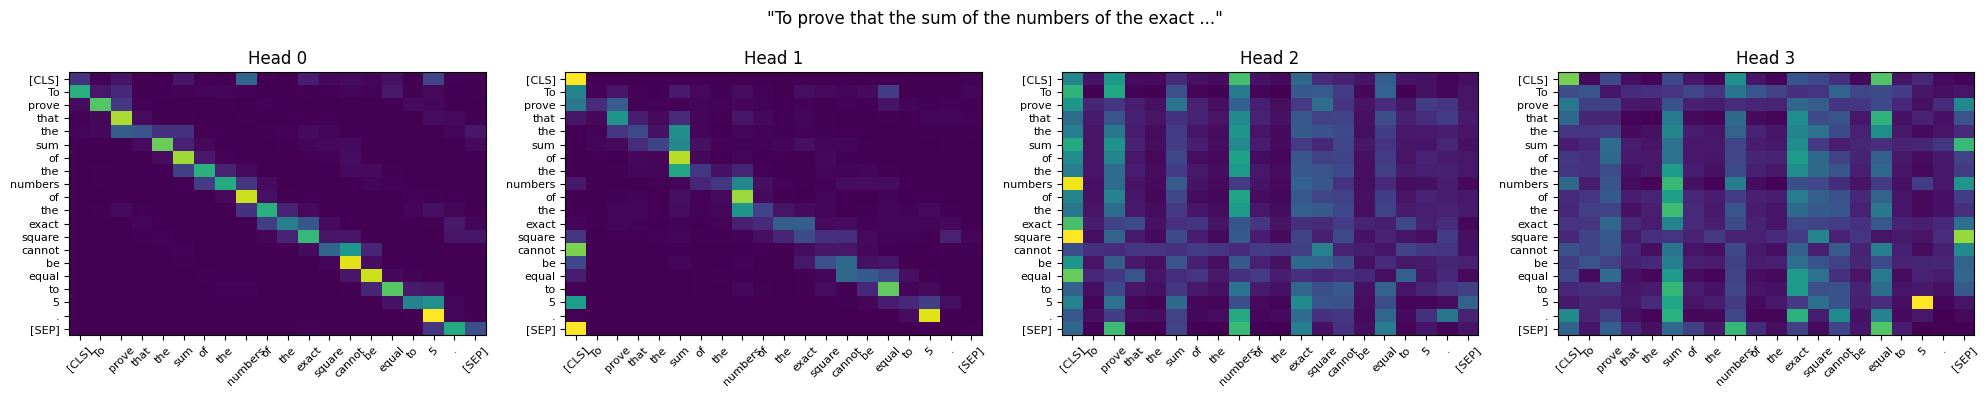


--- Текст 2 ---


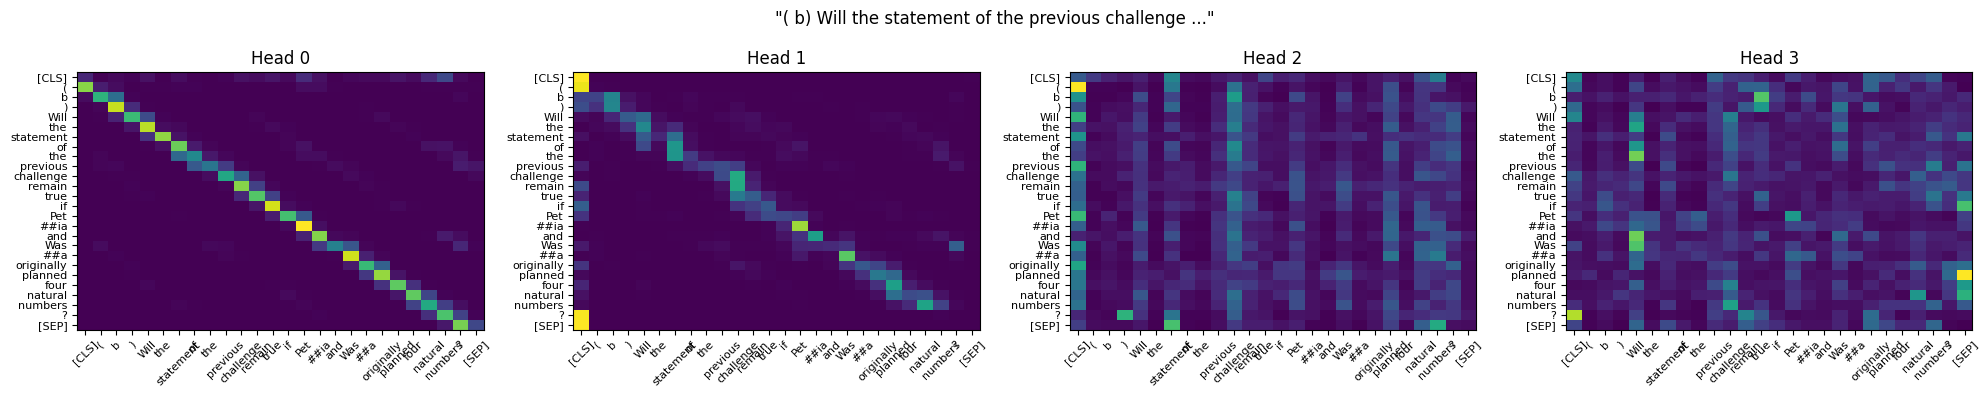


--- Текст 3 ---


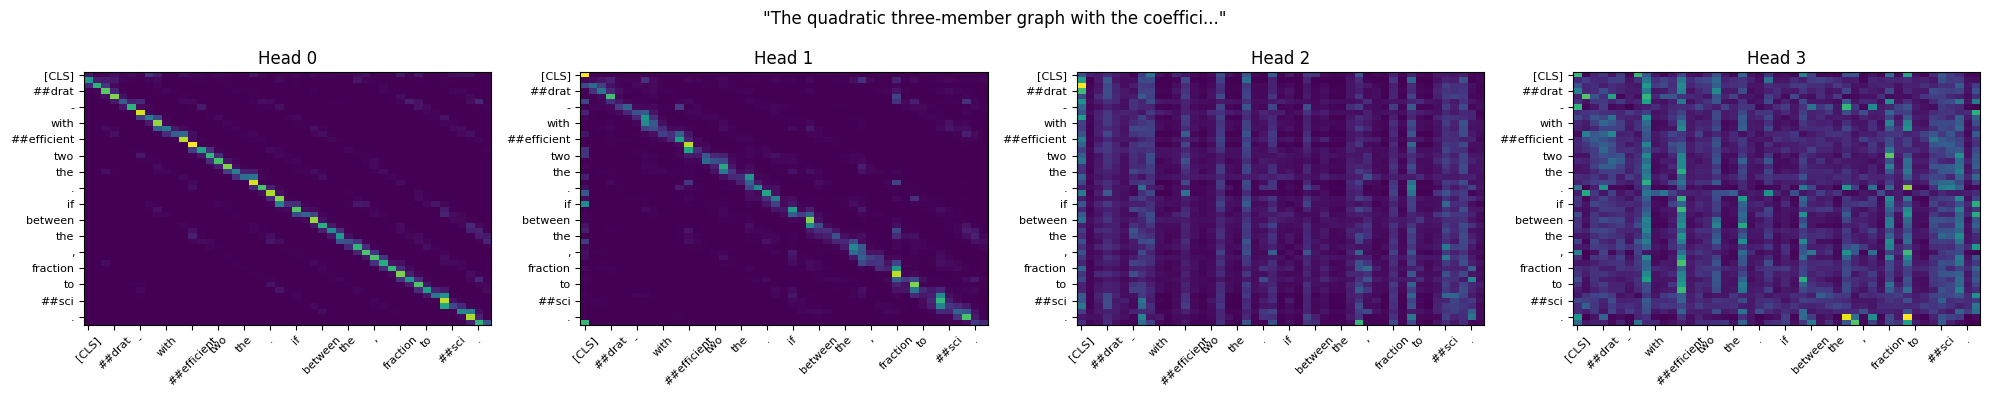

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: tbs17/MathBert
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



--- Текст 1 ---


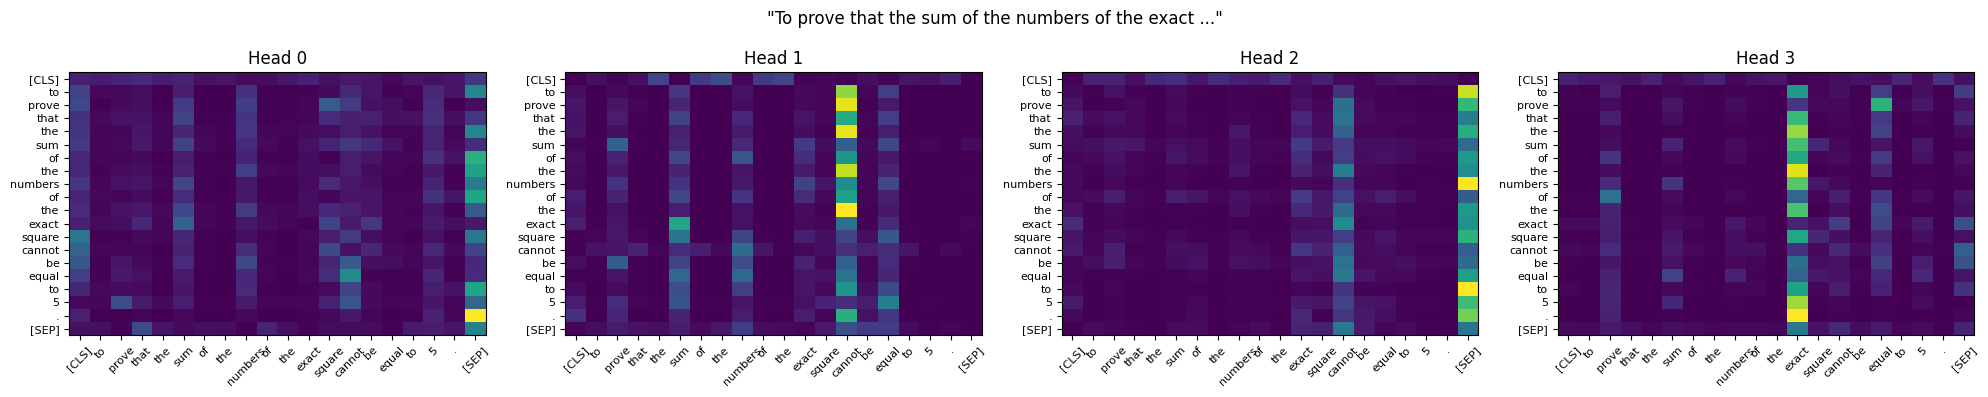


--- Текст 2 ---


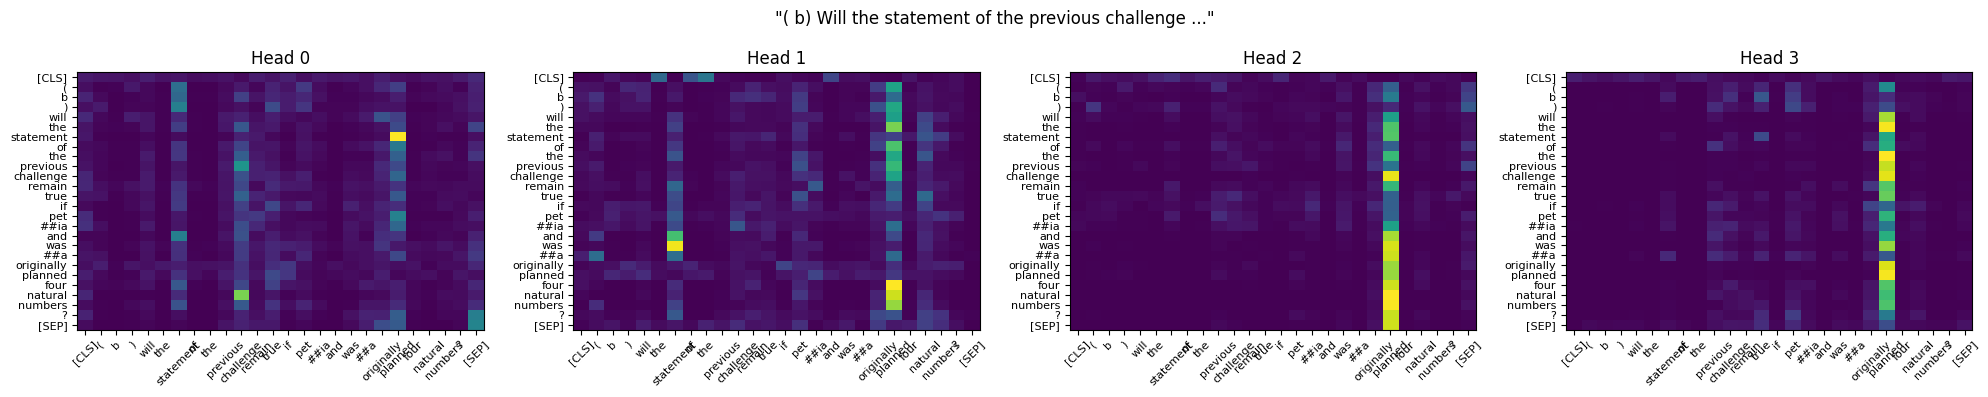


--- Текст 3 ---


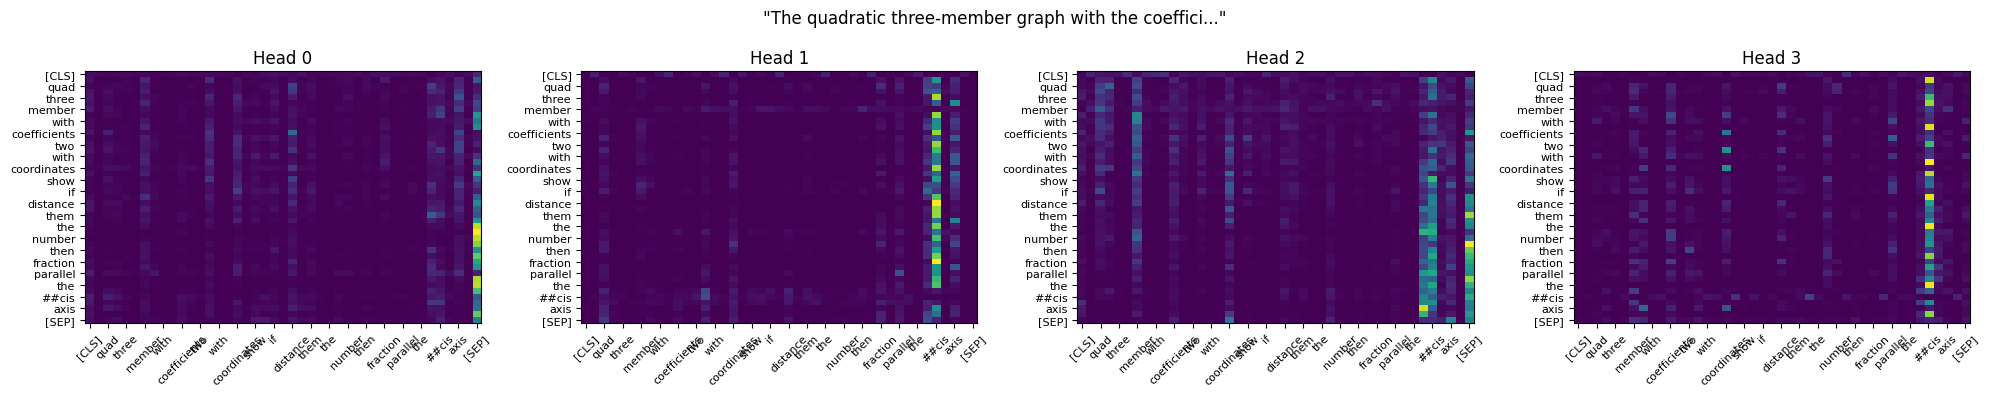

In [16]:
texts_to_analyze = texts[:3]  # первые 3 текста

for i, text in enumerate(texts_to_analyze):
    print(f"{i+1}. {text[:100]}...")

# rubert-tiny2 до обучения
rubert_tiny_untrained = TransformerClassificationModel(
    'cointegrated/rubert-tiny2',
    num_classes=num_classes,
)

for i, text in enumerate(texts_to_analyze):
    print(f"\n--- Текст {i+1} ---")
    draw_first_layer_attention_maps([0, 1, 2, 3], text, rubert_tiny_untrained, tokenizer)

# MathBert до обучения
math_bert_untrained = TransformerClassificationModel(
    'tbs17/MathBert',
    num_classes=num_classes,
)
math_bert_tokenizer = AutoTokenizer.from_pretrained('tbs17/MathBert')

for i, text in enumerate(texts_to_analyze):
    print(f"\n--- Текст {i+1} ---")
    draw_first_layer_attention_maps([0, 1, 2, 3], text, math_bert_untrained, math_bert_tokenizer)

#### rubert-tiny2 (размороженный backbone)
- Текст 1:

Head 0 - универсальная. Много яркий токенов, следит за общим контекстом всего предложения.

Head 1 - математические объекты + действия. Она отвечает за смысловое ядро задачи: что доказываем, с чем, какое условие, какой результат. "the" стал ярче — возможно, модель начала выделять определённый артикль как маркер последующего важного существительного.

Head 2 - ключевые элементы задачи

Head 3 - финальный результат. Выделены в основном prove, sum, numbers, exact, square, cannot, equal, 5 (в 1 месте)

**Модель адаптировалась под задачу, обновляя веса внимания через градиенты. Текст имел четкую структуру, что позволило головы специализироваться.**

- Текст 2: Специализация не проявилась - возможно, потому что текст содержит меньше явных математических маркеров (нет чисел, операторов, чёткого результата).

- Текст 3: Все головы выглядят примерно одинаково как до, так и после обучения. Слова выделены, но специализация слабее, потому что текст не требует явного действия или вычисления. Модель реагирует на математическую лексику, но не включает "режим решения задачи".

#### rubert-tiny2 (замороженный backbone)
- Текст 1: Карты внимания не изменились. Специализация отсутствует, все головы остались одинаковыми. Веса backbone не обновлялись.
- Текст 2: Карта почти не изменилась - головы остались похожими, без ярко выраженной специализации
- Текст 3: Без изменений

**При замороженном backbone веса механизма внимания не обновляются, поэтому головы не могут перераспределить роли. Обучается только классификационная голова.**

### Задание 8 (1 балл)

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают? Почему?


rubert-tiny2 (размороженный backbone)

Текст 1: To prove that the sum of the numbers of the exact square cannot be equal to 5....


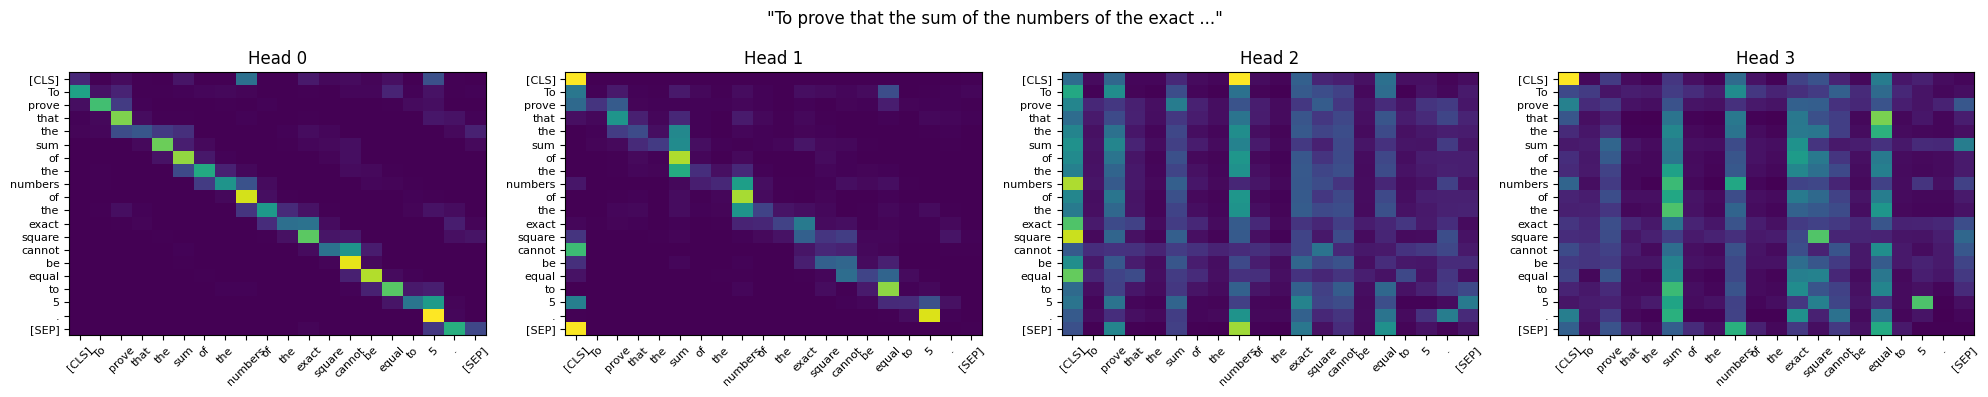


Текст 2: ( b) Will the statement of the previous challenge remain true if Petia and Wasa ...


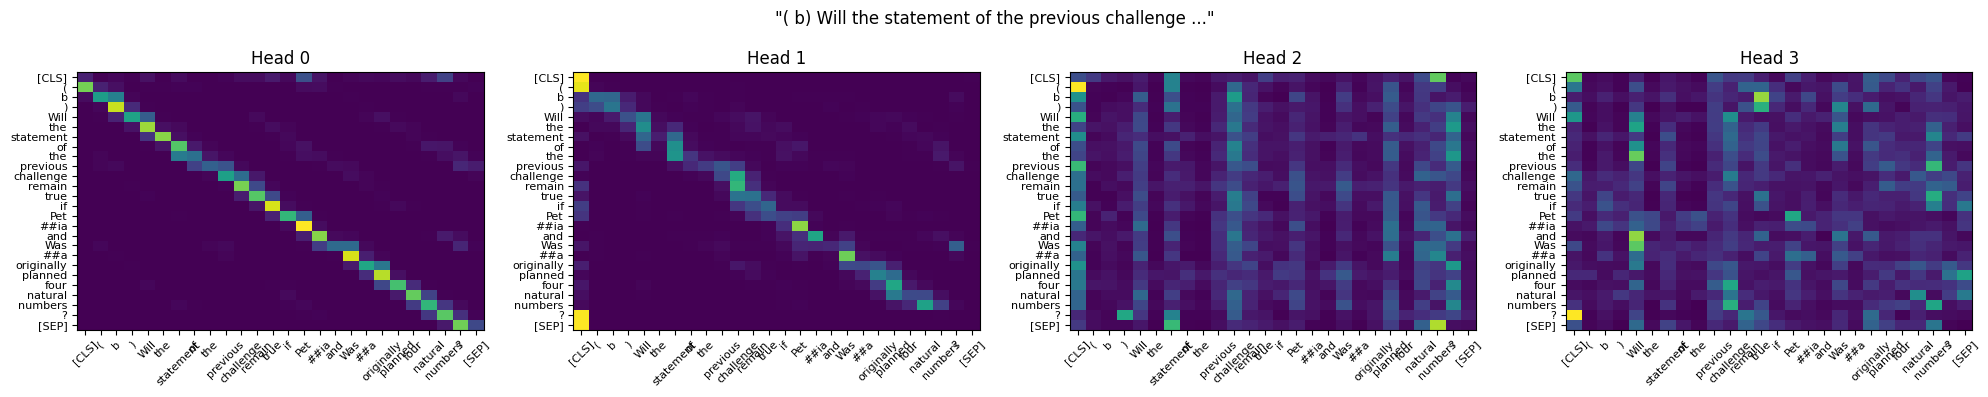


Текст 3: The quadratic three-member graph with the coefficients has two points with the c...


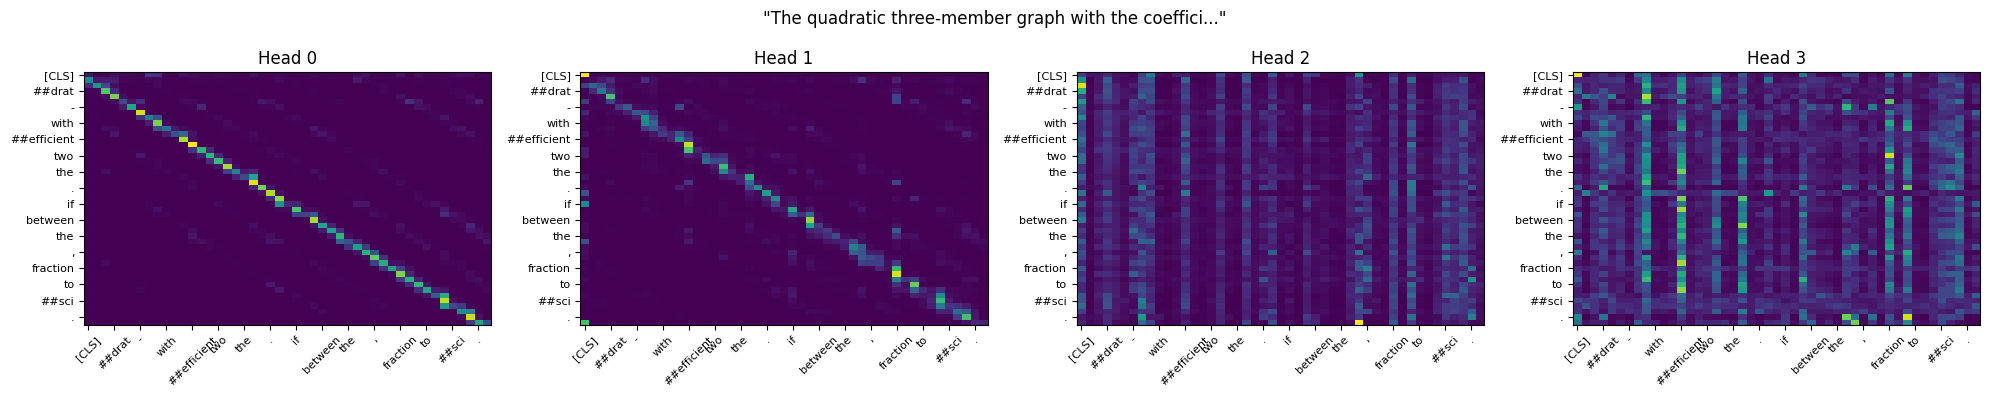


rubert-tiny2 (замороженный backbone)

Текст 1: To prove that the sum of the numbers of the exact square cannot be equal to 5....


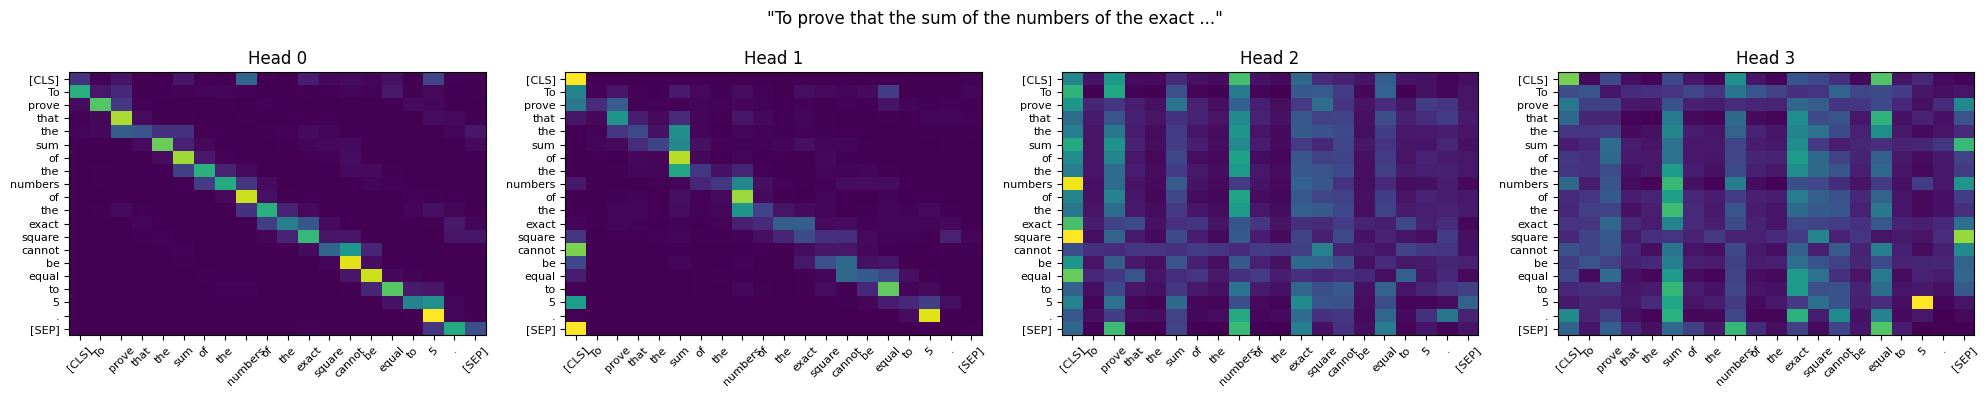


Текст 2: ( b) Will the statement of the previous challenge remain true if Petia and Wasa ...


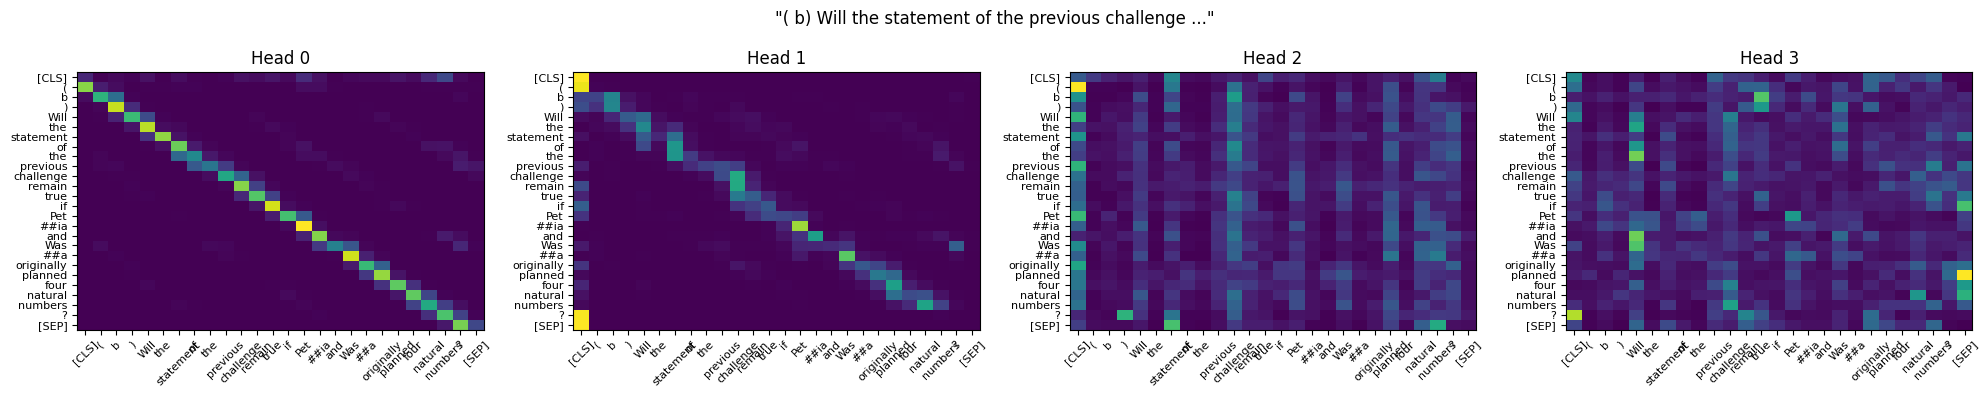


Текст 3: The quadratic three-member graph with the coefficients has two points with the c...


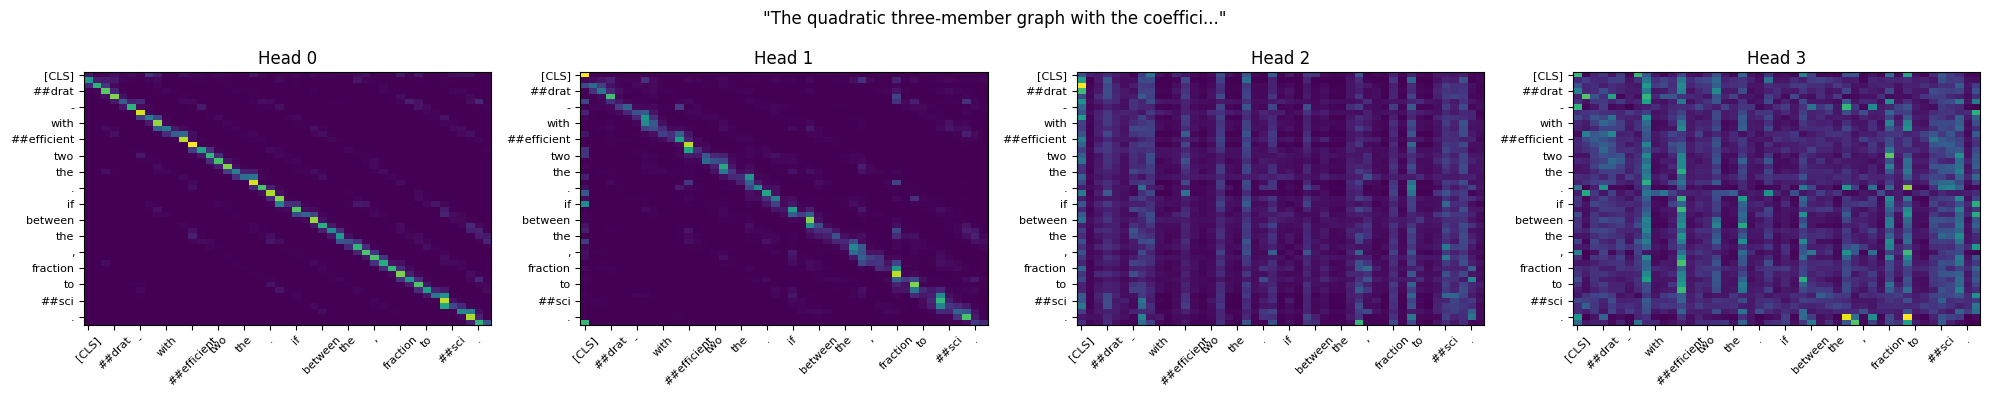


MathBert (размороженный backbone)

Текст 1: To prove that the sum of the numbers of the exact square cannot be equal to 5....


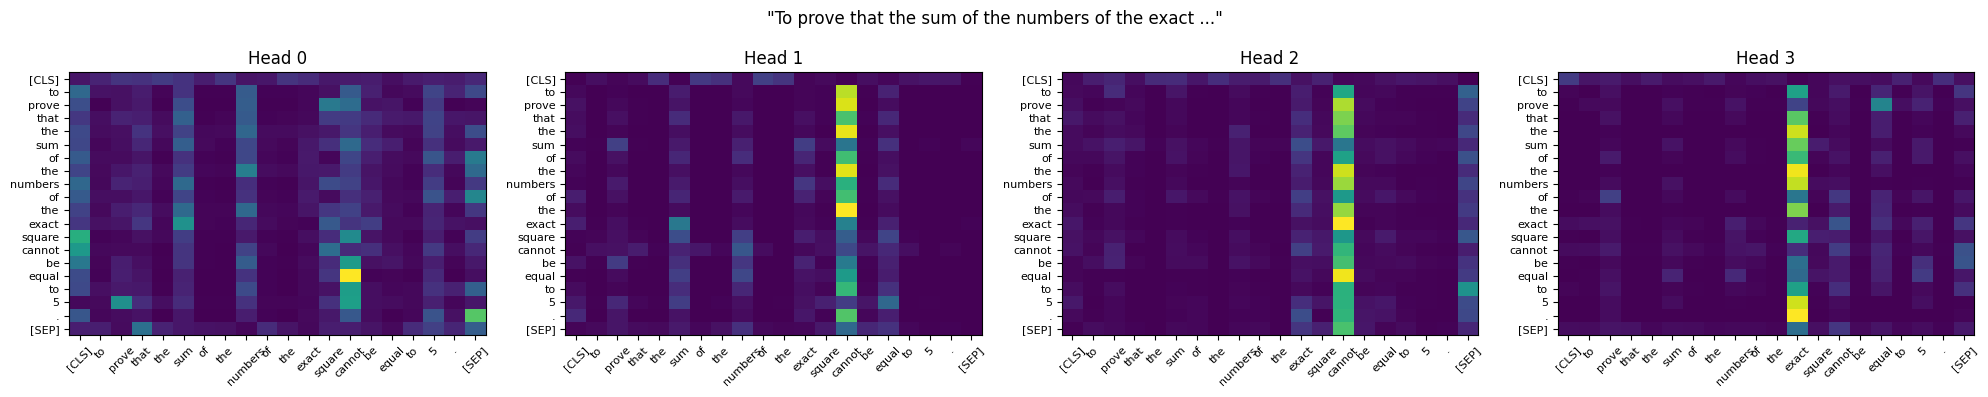


Текст 2: ( b) Will the statement of the previous challenge remain true if Petia and Wasa ...


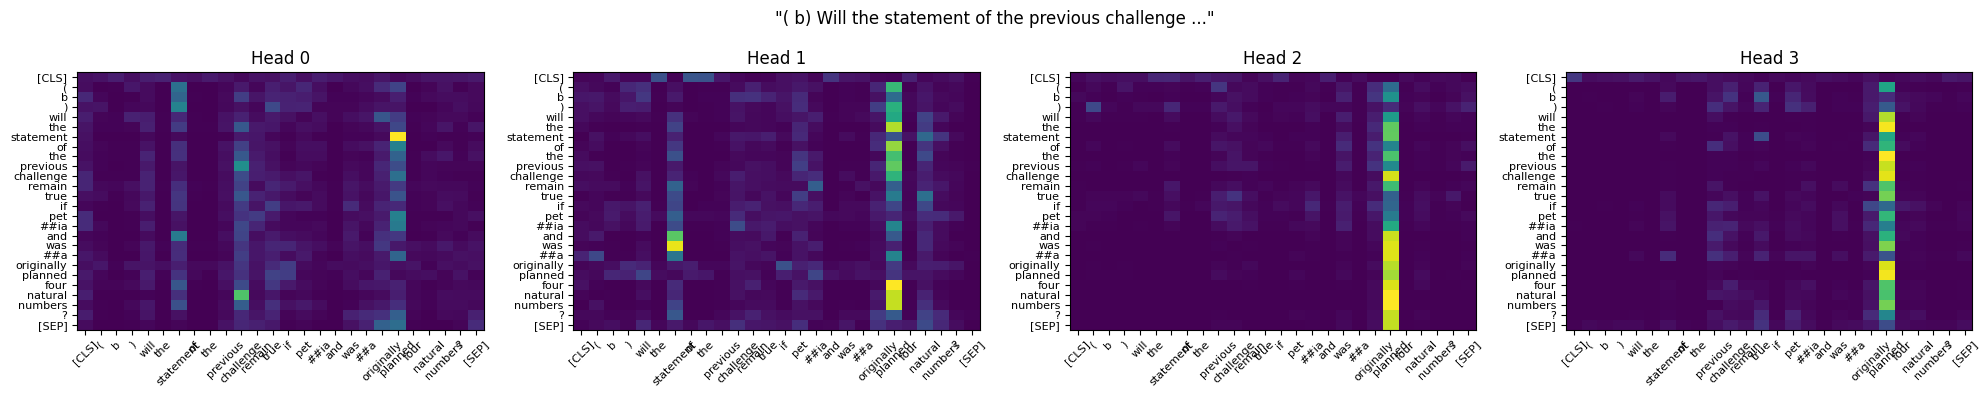


Текст 3: The quadratic three-member graph with the coefficients has two points with the c...


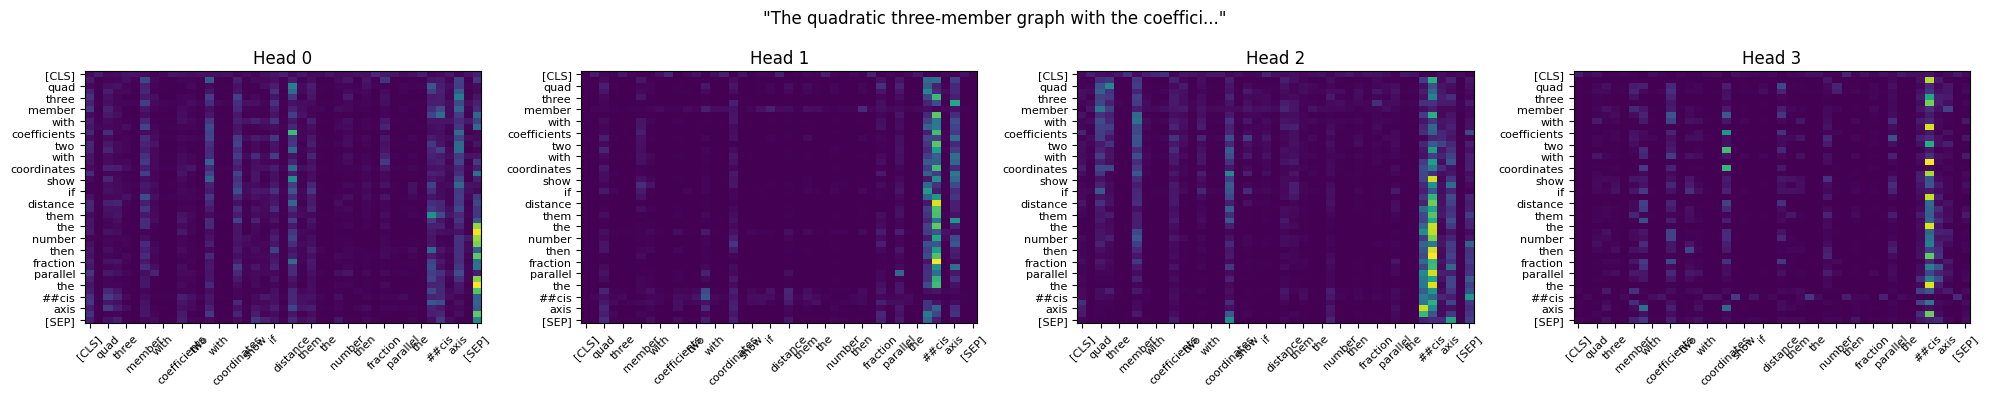


MathBert (замороженный backbone)

Текст 1: To prove that the sum of the numbers of the exact square cannot be equal to 5....


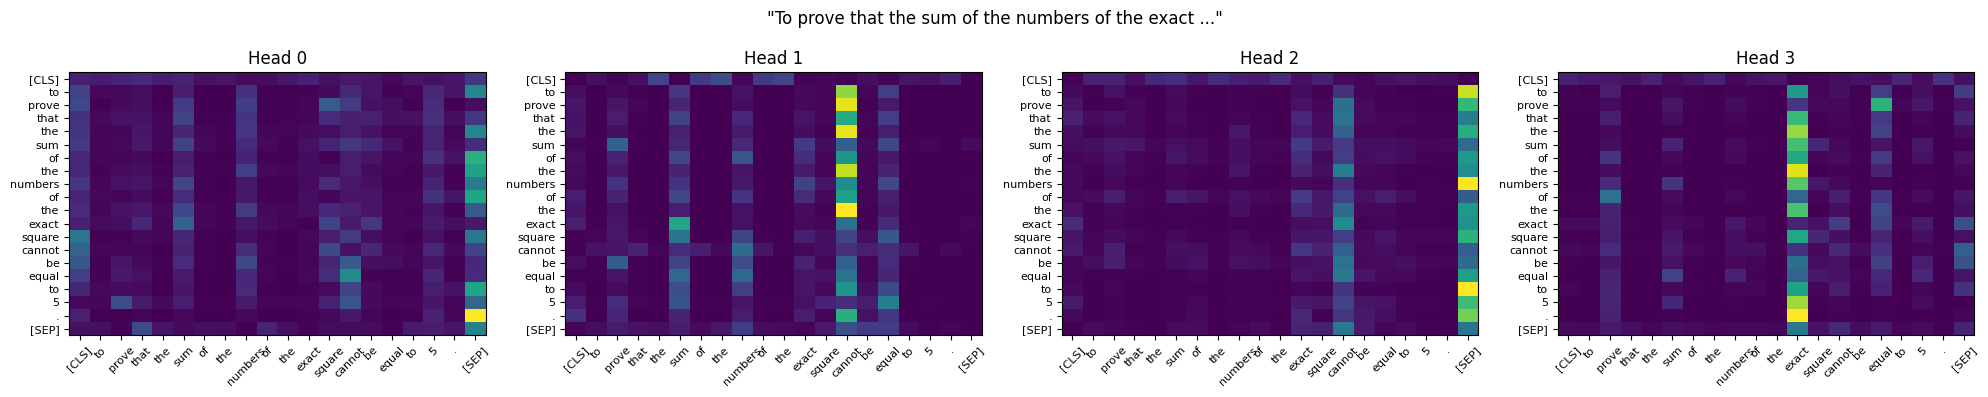


Текст 2: ( b) Will the statement of the previous challenge remain true if Petia and Wasa ...


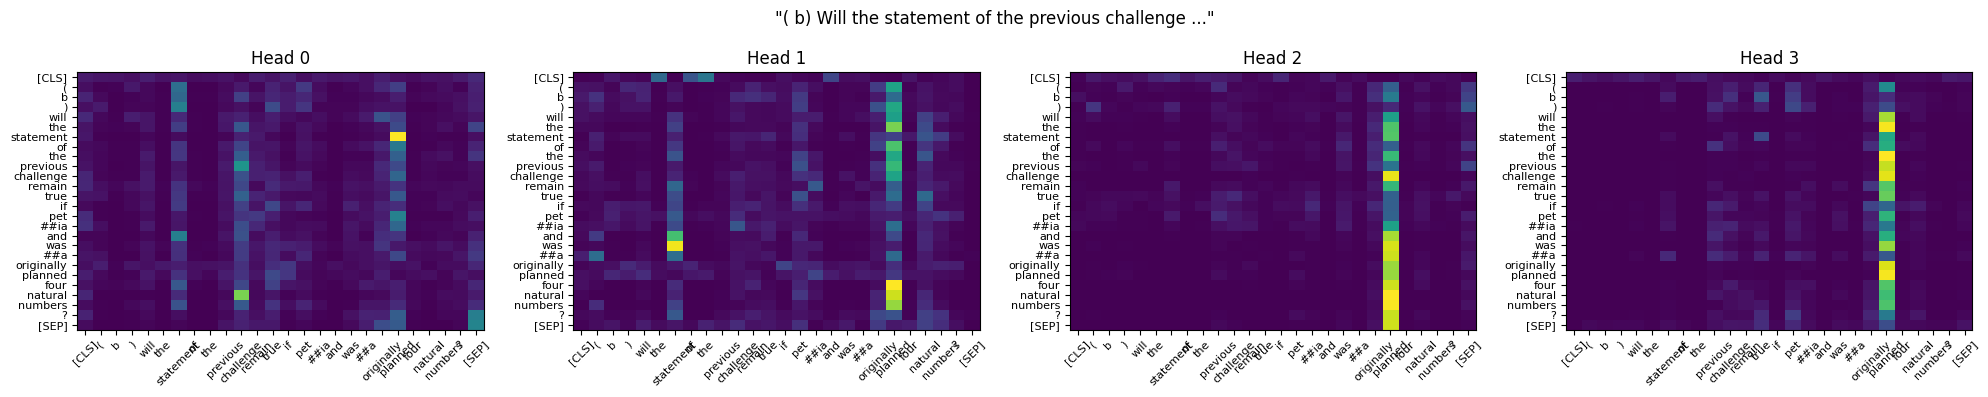


Текст 3: The quadratic three-member graph with the coefficients has two points with the c...


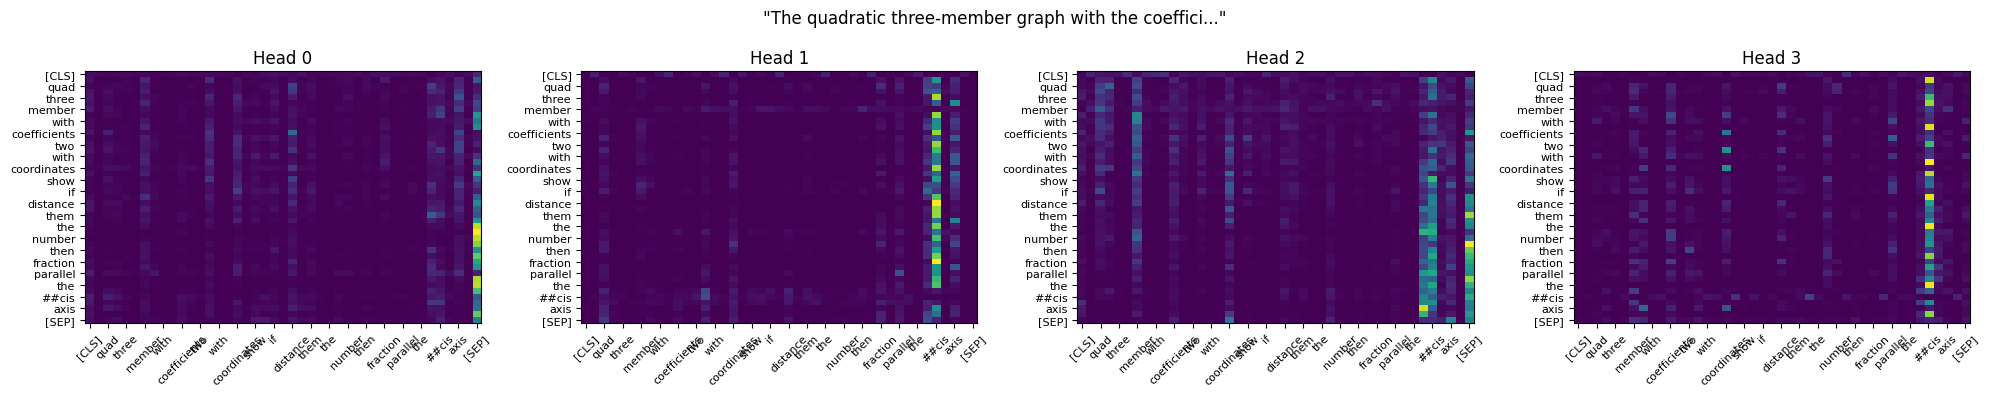

In [17]:
# rubert-tiny2 после обучения (размороженный)
print("\nrubert-tiny2 (размороженный backbone)")
for i, text in enumerate(texts_to_analyze):
    print(f"\nТекст {i+1}: {text[:80]}...")
    draw_first_layer_attention_maps([0, 1, 2, 3], text, rubert_tiny_full_finetuned, tokenizer)

# rubert-tiny2 после обучения (замороженный)
print("\nrubert-tiny2 (замороженный backbone)")
for i, text in enumerate(texts_to_analyze):
    print(f"\nТекст {i+1}: {text[:80]}...")
    draw_first_layer_attention_maps([0, 1, 2, 3], text, rubert_tiny_finetuned_with_freezed_backbone, tokenizer)

# MathBert после обучения (размороженный)
print("\nMathBert (размороженный backbone)")
for i, text in enumerate(texts_to_analyze):
    print(f"\nТекст {i+1}: {text[:80]}...")
    draw_first_layer_attention_maps([0, 1, 2, 3], text, math_bert_unfrozen, math_bert_tokenizer)

# MathBert после обучения (замороженный)
print("\nMathBert (замороженный backbone)")
for i, text in enumerate(texts_to_analyze):
    print(f"\nТекст {i+1}: {text[:80]}...")
    draw_first_layer_attention_maps([0, 1, 2, 3], text, math_bert_frozen, math_bert_tokenizer)

### **Итог:**
#### rubert-tiny2 (размороженный backbone)
- Текст 1:

Head 0 - универсальная. Много яркий токенов, следит за общим контекстом всего предложения.

Head 1 - математические объекты + действия. Она отвечает за смысловое ядро задачи: что доказываем, с чем, какое условие, какой результат. "the" стал ярче — возможно, модель начала выделять определённый артикль как маркер последующего важного существительного.

Head 2 - ключевые элементы задачи

Head 3 - финальный результат. Выделены в основном prove, sum, numbers, exact, square, cannot, equal, 5 (в 1 месте)

**Модель адаптировалась под задачу, обновляя веса внимания через градиенты. Текст имел четкую структуру, что позволило головы специализироваться.**

- Текст 2: Специализация не проявилась - возможно, потому что текст содержит меньше явных математических маркеров (нет чисел, операторов, чёткого результата).

- Текст 3: Все головы выглядят примерно одинаково как до, так и после обучения. Слова выделены, но специализация слабее, потому что текст не требует явного действия или вычисления. Модель реагирует на математическую лексику, но не включает "режим решения задачи".

#### rubert-tiny2 (замороженный backbone)
- Текст 1: Карты внимания не изменились. Специализация отсутствует, все головы остались одинаковыми. Веса backbone не обновлялись.
- Текст 2: Карта почти не изменилась - головы остались похожими, без ярко выраженной специализации
- Текст 3: Без изменений

**При замороженном backbone веса механизма внимания не обновляются, поэтому головы не могут перераспределить роли. Обучается только классификационная голова.**

#### MathBert (размороженный backbone)
MathBert с размороженным backbone не смог адаптировать головы внимания ни на одном тексте. Это подтверждает, что модель переобучилась из-за слишком большого learning rate (2e-5). В отличие от rubert-tiny2, который успешно специализировал головы на вычислительном тексте, MathBert не показал специализации вообще. Для MathBert с размороженным backbone нужен меньший learning rate

#### MathBert (замороженный backbone)
Замороженный backbone не позволяет обновлять веса механизма внимания, поэтому головы остаются в исходном состоянии независимо от текста. Специализация отсутствует на всех трех текстах.